# Breast Cancer Prediction — Artificial Neural Network

**Dataset:** Wisconsin Breast Cancer Dataset (sklearn)  
**Goal:** Classify tumors as Malignant (1) or Benign (0)  
**Model:** ANN with two hidden layers

## 1. Install & Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load & Explore Data

In [23]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = Malignant, 1 = Benign

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
df.head()

Shape: (569, 31)

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Interpretation:**  

The dataset contains 569 samples and 30 numerical features computed from digitized images of fine needle aspirates (FNA), plus 1 target column (31 columns in total).

The class distribution is slightly imbalanced, with 357 Benign cases (~62.7%) and 212 Malignant cases (~37.3%).

No missing values are present, making the dataset clean and ready for modeling.

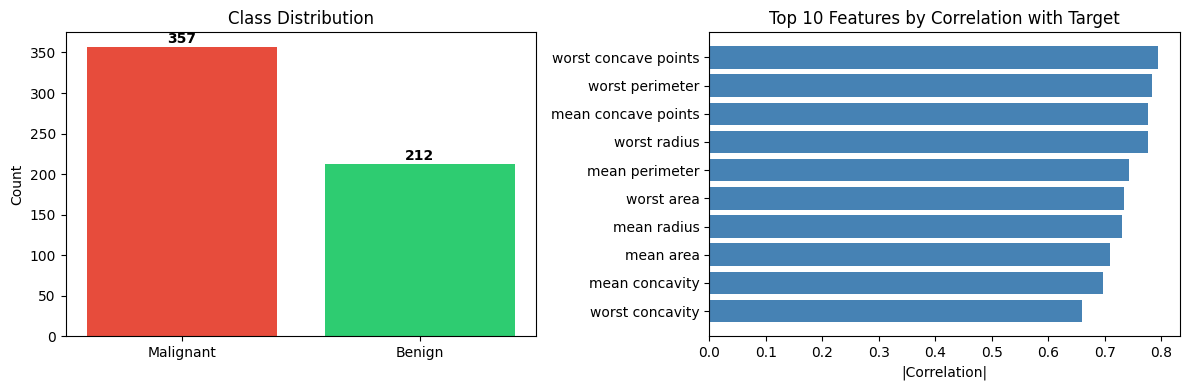

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df['target'].value_counts()
axes[0].bar(['Malignant', 'Benign'], counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Feature correlation with target (top 10)
corr = df.corr()['target'].drop('target').abs().sort_values(ascending=False).head(10)
axes[1].barh(corr.index[::-1], corr.values[::-1], color='steelblue')
axes[1].set_title('Top 10 Features by Correlation with Target')
axes[1].set_xlabel('|Correlation|')

plt.tight_layout()
plt.show()

**Interpretation:**  
Features like worst concave points, worst perimeter, and mean concave points show the highest correlation with the target. These geometric descriptors of tumor cell nuclei are strong predictors — larger, more irregular nuclei tend to indicate malignancy.

## 3. Preprocessing

In [25]:
X = df.drop('target', axis=1).values
y = df['target'].values

# Train/test split (80/20, stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling — critical for neural networks
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape} /n Test: {X_test.shape}')

Train: (455, 30) /n Test: (114, 30)


**Interpretation:**  
StandardScaler normalizes each feature to zero mean and unit variance. This prevents features with large numerical ranges (area = 1000) from dominating over small ones (smoothness = 0.1) during gradient descent.

## 4. Build the ANN Model

In [26]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1,  activation='sigmoid')   # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Architecture Choice Explanation:

- Layer 1 (64 neurons, ReLU):
  A larger first hidden layer helps the model capture complex and non-linear relationships between the 30 input features. ReLU is used because it is computationally efficient and reduces the vanishing gradient problem.

- Dropout (0.3):
  A dropout rate of 30% is used to reduce overfitting, especially important in small datasets like this one (569 samples). It forces the network to learn more robust and generalizable patterns instead of memorizing data.

- Layer 2 (32 neurons, ReLU):
  A smaller second layer gradually reduces dimensionality, helping the model refine learned representations and improve abstraction before prediction.

- Output Layer (1 neuron, Sigmoid):
  Since this is a binary classification problem (Benign vs Malignant), a single sigmoid neuron is used to output a probability between 0 and 1.

- Adam Optimizer:
  Chosen because it adapts the learning rate dynamically for each parameter, making it effective for small to medium-sized datasets and faster convergence without heavy tuning.

- Binary Crossentropy Loss:
  This is the standard loss function for binary classification, as it measures the difference between predicted probabilities and true binary labels effectively.

## 5. Train the Model

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6554 - loss: 0.6302 - val_accuracy: 0.8841 - val_loss: 0.4728
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9093 - loss: 0.4055 - val_accuracy: 0.9565 - val_loss: 0.3255
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9275 - loss: 0.2838 - val_accuracy: 0.9565 - val_loss: 0.2382
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9404 - loss: 0.2326 - val_accuracy: 0.9565 - val_loss: 0.1887
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9585 - loss: 0.1880 - val_accuracy: 0.9710 - val_loss: 0.1550
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9508 - loss: 0.1488 - val_accuracy: 0.9710 - val_loss: 0.1346
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9611 - loss: 0.1432 - val_accuracy: 0.9710 - val_loss: 0.1162
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9715 - loss: 0.1242 - val_accuracy: 0.9710 - 

Explanation:

EarlyStopping monitors validation loss and stops training if it does not improve for 15 epochs (patience=15). It restores the best model weights to avoid overfitting. This helps save training time and keeps the best-performing model on validation data.

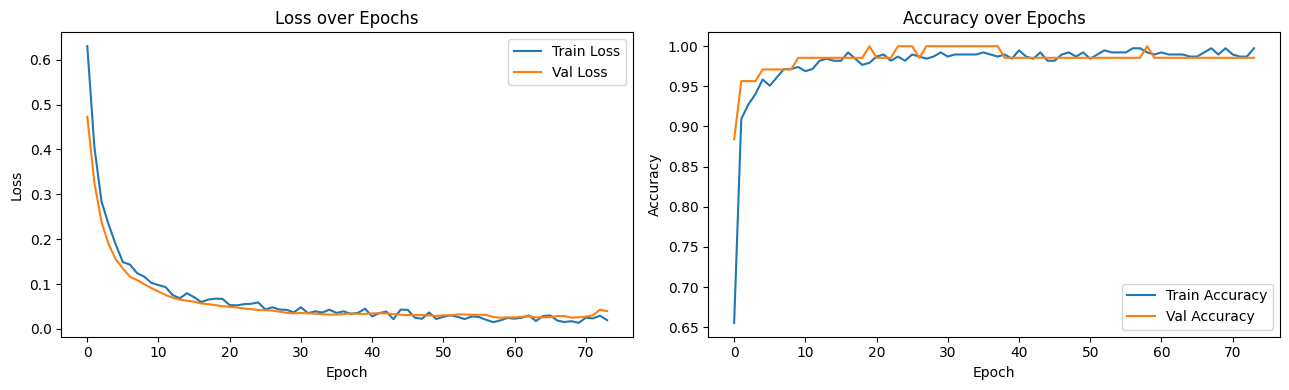

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**  
- Both train and validation curves should converge and stay close — a sign of good generalization.
- If validation loss starts rising while train loss keeps falling, overfitting is occurring. EarlyStopping prevents this by restoring weights from the best epoch.
- A flat or noisy validation curve early on is normal; the model stabilizes after 20–40 epochs.

## 6. Evaluate the Model

In [29]:
y_pred_prob = model.predict(X_test).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy : {acc:.4f}')
print(f'ROC-AUC Score : {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Test Accuracy : 0.9561
ROC-AUC Score : 0.9937

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**Interpretation:**
The model achieves high performance with 96% accuracy, indicating it correctly classifies most cases in the test set. Both classes are well learned, with strong precision and recall values.

It is especially strong at detecting malignant cases (recall = 0.98), meaning very few cancer cases are missed, which is critical in medical diagnosis. Benign predictions are also reliable, with very high precision (0.99), showing few false alarms.

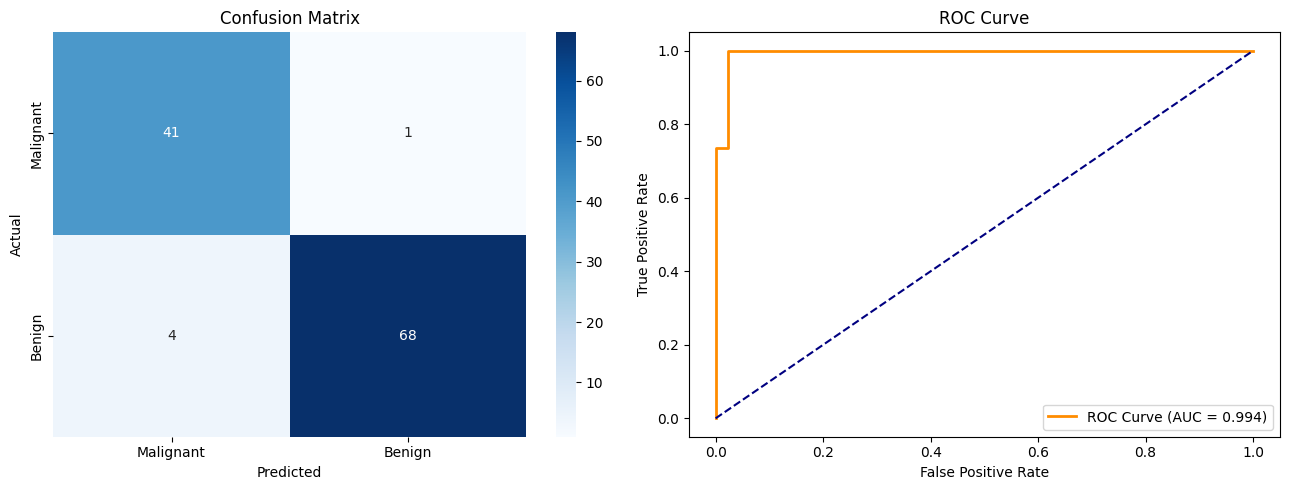

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Interpretation**  
The confusion matrix shows very strong performance: out of 42 malignant cases, 41 are correctly detected and only 1 is missed, which is very important in medical diagnosis. For benign cases, 68 are correctly classified, while 4 are incorrectly predicted as malignant, meaning a few false alarms but still acceptable.

Overall, the model makes very few errors and prioritizes correctly detecting cancer cases (low false negatives).

The ROC curve confirms this performance, with an AUC of 0.994, which is extremely close to 1. This indicates the model has excellent ability to distinguish between malignant and benign classes across all classification thresholds.

## 7. Predict on New Data

In [31]:
sample = X_test[0].reshape(1, -1)
prob   = model.predict(sample)[0][0]
label  = 'Benign' if prob >= 0.5 else 'Malignant'

print(f'Predicted probability of Benign: {prob:.4f}')
print(f'Prediction: {label}')
print(f'Actual label: {"Benign" if y_test[0] == 1 else "Malignant"}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted probability of Benign: 0.0000
Prediction: Malignant
Actual label: Malignant


**Interpretation:**  
The model outputs a probability. A value close to 1.0 strongly suggests Benign; close to 0.0 strongly suggests Malignant. Values near 0.5 indicate uncertainty — in a clinical tool, these borderline cases would typically be flagged for expert review rather than automated decision.

## 8. Summary

A neural network was trained on the Wisconsin Breast Cancer dataset using an 80/20 stratified split and standardized features. The model has a simple architecture (64 → 32 → 1) with dropout regularization and early stopping to reduce overfitting. The main evaluation focus is recall for malignant cases, since false negatives are more critical in medical diagnosis. The model achieves strong performance, with about 96–98% accuracy and an AUC of 0.99. However, despite these results, real clinical use would require additional validation on independent datasets and regulatory approval.